<a href="https://colab.research.google.com/github/Deepak969686/CEI-Internship-assignments/blob/main/Week4_%20Assignment_Deepak%20kumar%20saini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3035s 18us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

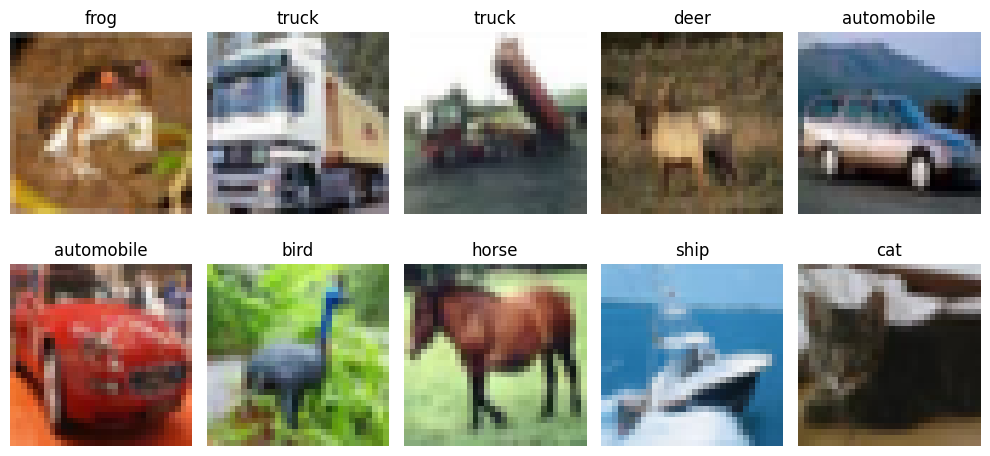

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

In [5]:
early_stop=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [8]:
ann_model=models.Sequential([
    layers.Dense(1024,activation='relu',input_shape=(3072,)),
    layers.Dropout(0.4),

    layers.Dense(512,activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256,activation='relu'),

    layers.Dense(10,activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history=ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 72ms/step - accuracy: 0.2419 - loss: 2.0456 - val_accuracy: 0.2944 - val_loss: 1.9070
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.2916 - loss: 1.9184 - val_accuracy: 0.3422 - val_loss: 1.8422
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 71ms/step - accuracy: 0.3082 - loss: 1.8796 - val_accuracy: 0.3472 - val_loss: 1.8353
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 66ms/step - accuracy: 0.3143 - loss: 1.8577 - val_accuracy: 0.3582 - val_loss: 1.8379
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 71ms/step - accuracy: 0.3224 - loss: 1.8422 - val_accuracy: 0.3564 - val_loss: 1.8232
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.3291 - loss: 1.8273 - val_accuracy: 0.3558 - val_loss: 1.7789
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.3396 - loss: 1.8059 - val_accuracy: 0.3882 - val_loss: 1.7636
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 70ms/step - accuracy: 0.3462 - loss: 1.7903 - 

In [9]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4018 - loss: 1.7245
ANN Test Accuracy: 0.4018000066280365


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [10]:
cnn_model=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10,activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history=cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 129ms/step - accuracy: 0.4700 - loss: 1.4851 - val_accuracy: 0.5702 - val_loss: 1.2389
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.6128 - loss: 1.1109 - val_accuracy: 0.6214 - val_loss: 1.0695
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 127ms/step - accuracy: 0.6744 - loss: 0.9416 - val_accuracy: 0.6866 - val_loss: 0.8967
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 131ms/step - accuracy: 0.7155 - loss: 0.8228 - val_accuracy: 0.6822 - val_loss: 0.9130
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.7435 - loss: 0.7329 - val_accuracy: 0.7246 - val_loss: 0.8418
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 129ms/step - accuracy: 0.7694 - loss: 0.6599 - val_accuracy: 0.6844 - val_loss: 0.9836
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7948 - loss: 0.5834 - val_accuracy: 0.6828 - val_loss: 1.0637
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.8141 - loss:

In [11]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7163 - loss: 0.8667
CNN Test Accuracy: 0.7163000106811523


# Accuracy Curve


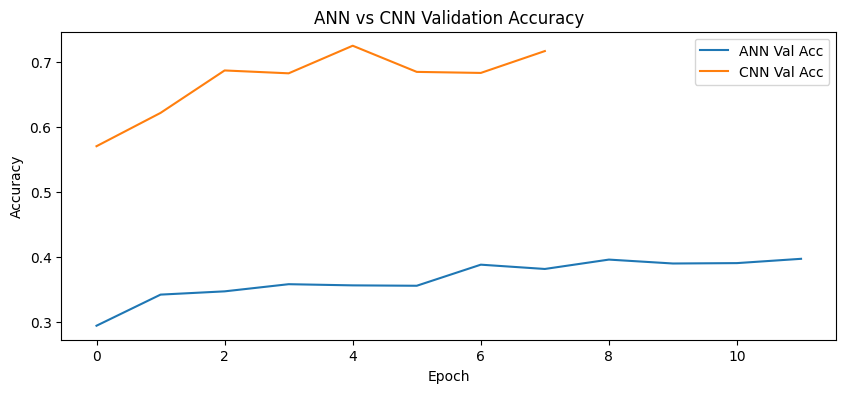

In [12]:
plt.figure(figsize=(10,4))

plt.plot(
    ann_history.history['val_accuracy'],
    label='ANN Val Acc'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='CNN Val Acc'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")

plt.legend()
plt.show()

# Loss Curve

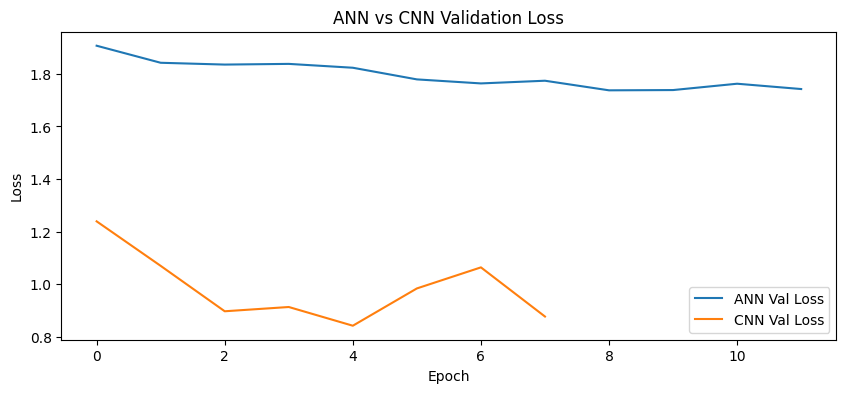

In [13]:
plt.figure(figsize=(10,4))

plt.plot(
    ann_history.history['val_loss'],
    label="ANN Val Loss"
)

plt.plot(
    cnn_history.history['val_loss'],
    label="CNN Val Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN vs CNN Validation Loss")

plt.legend()
plt.show()

## 📈 Compare Learning Curves

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [14]:
data_augmentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model=models.Sequential([
    data_augmentation,

    layers.Conv2D(32,3,activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10,activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history=aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 109ms/step - accuracy: 0.3429 - loss: 1.7804 - val_accuracy: 0.4500 - val_loss: 1.5132
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 105ms/step - accuracy: 0.4634 - loss: 1.4858 - val_accuracy: 0.4848 - val_loss: 1.5203
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 107ms/step - accuracy: 0.5142 - loss: 1.3691 - val_accuracy: 0.5930 - val_loss: 1.1305


# 📊 Final Comparison Table

In [15]:
aug_test_loss,aug_test_acc=aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

comparison=pd.DataFrame({
    "Model":[
        "ANN",
        "CNN",
        "CNN + Augmentation"
    ],

    "Test Accuracy":[
        ann_test_acc,
        cnn_test_acc,
        aug_test_acc
    ]
})

comparison

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4518 - loss: 1.5030


,Model,Test Accuracy
0,ANN,0.4018
1,CNN,0.7163
2,CNN + Augmentation,0.4518


# ✅ Conclusion

In this project, we implemented and compared different deep learning approaches for CIFAR-10 image classification.

### 🔹 ANN Model
- ANN was able to classify images after flattening them into vectors.
- Increasing ANN layers improved learning capacity.
- However, ANN loses spatial information present in images.

### 🔹 CNN Model
- CNN performed better because it preserved image structure using:
  - Convolution layers
  - Pooling layers
  - Feature extraction
  - Batch Normalization
  - Dropout

### 🔹 Training Improvements
To improve model performance and generalization, we applied:
- Increased training epochs
- EarlyStopping to prevent overfitting
- Data Augmentation using random flip, rotation, and zoom

### 📊 Final Observation
- ANN achieved lower performance because it ignores spatial features.
- CNN achieved higher accuracy by learning visual patterns.
- CNN with augmentation provided better generalization on unseen data.

Therefore, CNN-based architectures are more suitable than ANN for image classification tasks.